In [1]:
# Colab setup cell: run this first if you opened the notebook from GitHub in Colab.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/lblommesteyn/march_madness_wai_wsac_workshop.git"
STABLE_DIR = Path("/content")
REPO_DIR = Path("/content/march_madness_wai_wsac_workshop")

def run_cmd(cmd, cwd=None, check=True):
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout.strip())
    if result.stderr:
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(cmd)}")
    return result

def git_lfs_available():
    return run_cmd(["git", "lfs", "version"], check=False).returncode == 0

if "google.colab" in sys.modules:
    STABLE_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(STABLE_DIR)
    if not git_lfs_available():
        run_cmd(["apt-get", "-qq", "update"])
        run_cmd(["apt-get", "-qq", "install", "git-lfs"])
    if REPO_DIR.exists() and not (REPO_DIR / ".git").exists():
        print(f"Removing incomplete repo directory at {REPO_DIR}.")
        subprocess.run(["rm", "-rf", str(REPO_DIR)], check=False)
    if REPO_DIR.exists():
        print(f"Repo already exists at {REPO_DIR}, refreshing it.")
        run_cmd(["git", "pull"], cwd=REPO_DIR, check=False)
    else:
        run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)], cwd=STABLE_DIR)
    if git_lfs_available():
        run_cmd(["git", "lfs", "pull"], cwd=REPO_DIR, check=False)
    else:
        print("Warning: git-lfs is unavailable, so large files may not download.")
    os.chdir(REPO_DIR)
    print("Colab repo setup complete.")
else:
    print("Colab setup skipped because this notebook is not running in Google Colab.")

print("Working directory:", Path.cwd())


Colab setup skipped because this notebook is not running in Google Colab.
Working directory: C:\Users\16476\mm_intro_to_ml


# March Madness Model Lab: Men + Women

This notebook is designed to answer a practical question:
**what should you actually trust for March Madness prediction once you compare models, baselines, calibration, and bracket outcomes?**

It covers:
- dataset audit for men's and women's March Mania CSVs
- season-level feature engineering
- matchup-level supervised learning
- rolling backtests against the better-seed baseline
- calibration and feature importance
- historical bracket simulation and visualization
- an optional latent offense-defense PyMC section


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import pymc as pm
    import arviz as az
    HAS_PYMC = True
except Exception:
    HAS_PYMC = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

print("XGBoost available:", HAS_XGB)
print("PyMC available:", HAS_PYMC)


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


XGBoost available: True
PyMC available: True


## 1. Load and audit the data

The notebook uses local Kaggle-style CSVs. It is robust to partial availability:
men's and women's pipelines run independently, and advanced features are only added when the needed file exists.


In [3]:
FILES = {
    "M": {
        "regular_compact": "MRegularSeasonCompactResults.csv",
        "regular_detailed": "MRegularSeasonDetailedResults.csv",
        "tourney_compact": "MNCAATourneyCompactResults.csv",
        "tourney_detailed": "MNCAATourneyDetailedResults.csv",
        "seeds": "MNCAATourneySeeds.csv",
        "slots": "MNCAATourneySlots.csv",
        "teams": "MTeams.csv",
        "massey": "MMasseyOrdinals.csv",
    },
    "W": {
        "regular_compact": "WRegularSeasonCompactResults.csv",
        "regular_detailed": "WRegularSeasonDetailedResults.csv",
        "tourney_compact": "WNCAATourneyCompactResults.csv",
        "tourney_detailed": "WNCAATourneyDetailedResults.csv",
        "seeds": "WNCAATourneySeeds.csv",
        "slots": "WNCAATourneySlots.csv",
        "teams": "WTeams.csv",
        "massey": "WMasseyOrdinals.csv",
    },
}


def read_csv_if_exists(path_str):
    path = Path(path_str)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="cp1252")


data = {entity: {key: read_csv_if_exists(path) for key, path in mapping.items()} for entity, mapping in FILES.items()}

audit_rows = []
for entity, mapping in data.items():
    for key, df in mapping.items():
        audit_rows.append({
            "entity": entity,
            "dataset": key,
            "available": df is not None,
            "rows": None if df is None else len(df),
            "cols": None if df is None else len(df.columns),
            "season_start": None if df is None or "Season" not in df.columns else int(df["Season"].min()),
            "season_end": None if df is None or "Season" not in df.columns else int(df["Season"].max()),
        })
audit_df = pd.DataFrame(audit_rows)
display(audit_df)


,entity,dataset,available,rows,cols,season_start,season_end
0,M,regular_compact,True,185865.0,8.0,1985.0,2024.0
1,M,regular_detailed,True,111817.0,34.0,2003.0,2024.0
2,M,tourney_compact,True,2451.0,8.0,1985.0,2023.0
3,M,tourney_detailed,True,1315.0,34.0,2003.0,2023.0
4,M,seeds,True,2490.0,3.0,1985.0,2023.0
5,M,slots,True,2452.0,4.0,1985.0,2023.0
6,M,teams,True,378.0,4.0,NaN,NaN
7,M,massey,True,5166105.0,5.0,2003.0,2024.0
8,W,regular_compact,True,120799.0,8.0,1998.0,2022.0
9,W,regular_detailed,True,51582.0,34.0,2010.0,2019.0


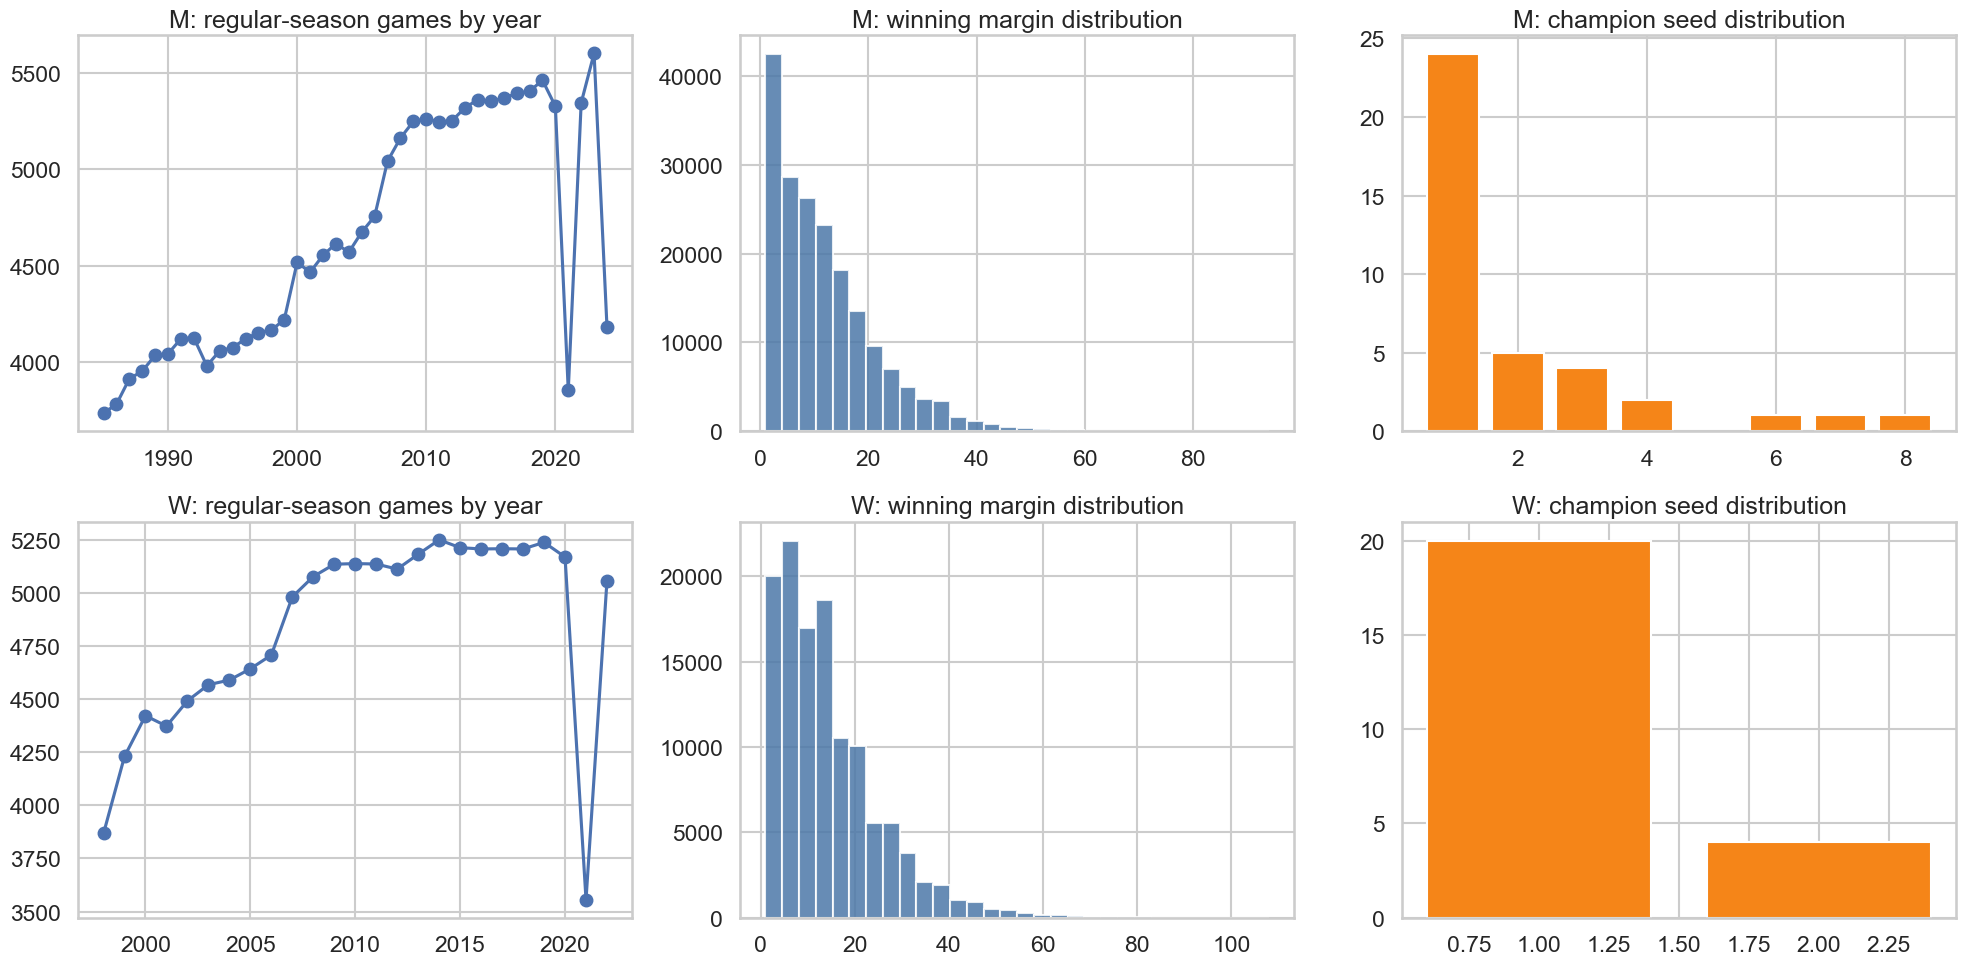

In [4]:
def parse_seed(seed):
    if pd.isna(seed):
        return np.nan
    match = re.search(r"(\d+)", str(seed))
    return float(match.group(1)) if match else np.nan


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for row_idx, entity in enumerate(["M", "W"]):
    regular = data[entity]["regular_compact"]
    tourney = data[entity]["tourney_compact"]
    seeds = data[entity]["seeds"]

    if regular is not None:
        season_counts = regular.groupby("Season").size()
        axes[row_idx, 0].plot(season_counts.index, season_counts.values, marker="o")
        axes[row_idx, 0].set_title(f"{entity}: regular-season games by year")

        margin = regular["WScore"] - regular["LScore"]
        axes[row_idx, 1].hist(margin, bins=30, color="#4c78a8", alpha=0.85)
        axes[row_idx, 1].set_title(f"{entity}: winning margin distribution")

    if tourney is not None and seeds is not None:
        last_day = tourney.groupby("Season")["DayNum"].transform("max")
        finals = tourney[last_day == tourney["DayNum"]].copy()
        champs = finals.merge(seeds[["Season", "TeamID", "Seed"]], left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"], how="left")
        champs["seed_num"] = champs["Seed"].map(parse_seed)
        champ_counts = champs["seed_num"].value_counts().sort_index()
        axes[row_idx, 2].bar(champ_counts.index.astype(int), champ_counts.values, color="#f58518")
        axes[row_idx, 2].set_title(f"{entity}: champion seed distribution")

plt.tight_layout()
plt.show()


## 2. Build season-level team features

We summarize each team-season using:
- record and scoring-margin features
- recent-form features from the last 10 games
- shooting/rebounding/turnover features when detailed results exist
- end-of-season Massey rank summaries when available


In [5]:
def stack_compact_games(df):
    winners = df.rename(columns={"WTeamID": "TeamID", "LTeamID": "OppTeamID", "WScore": "PointsFor", "LScore": "PointsAgainst", "WLoc": "GameLoc"})[
        ["Season", "DayNum", "TeamID", "OppTeamID", "PointsFor", "PointsAgainst", "GameLoc", "NumOT"]
    ].copy()
    winners["Won"] = 1

    losers = df.rename(columns={"LTeamID": "TeamID", "WTeamID": "OppTeamID", "LScore": "PointsFor", "WScore": "PointsAgainst"})[
        ["Season", "DayNum", "TeamID", "OppTeamID", "PointsFor", "PointsAgainst", "NumOT"]
    ].copy()
    losers["GameLoc"] = df["WLoc"].map({"H": "A", "A": "H", "N": "N"})
    losers["Won"] = 0

    games = pd.concat([winners, losers], ignore_index=True)
    games["Margin"] = games["PointsFor"] - games["PointsAgainst"]
    return games.sort_values(["Season", "TeamID", "DayNum"]).reset_index(drop=True)


def stack_detailed_games(df):
    winners = pd.DataFrame({
        "Season": df["Season"], "DayNum": df["DayNum"], "TeamID": df["WTeamID"], "OppTeamID": df["LTeamID"], "Won": 1,
        "PointsFor": df["WScore"], "PointsAgainst": df["LScore"],
        "FGM": df["WFGM"], "FGA": df["WFGA"], "FGM3": df["WFGM3"], "FGA3": df["WFGA3"], "FTM": df["WFTM"], "FTA": df["WFTA"],
        "OR": df["WOR"], "DR": df["WDR"], "Ast": df["WAst"], "TO": df["WTO"], "Stl": df["WStl"], "Blk": df["WBlk"],
        "OppOR": df["LOR"], "OppDR": df["LDR"], "OppTO": df["LTO"],
    })
    losers = pd.DataFrame({
        "Season": df["Season"], "DayNum": df["DayNum"], "TeamID": df["LTeamID"], "OppTeamID": df["WTeamID"], "Won": 0,
        "PointsFor": df["LScore"], "PointsAgainst": df["WScore"],
        "FGM": df["LFGM"], "FGA": df["LFGA"], "FGM3": df["LFGM3"], "FGA3": df["LFGA3"], "FTM": df["LFTM"], "FTA": df["LFTA"],
        "OR": df["LOR"], "DR": df["LDR"], "Ast": df["LAst"], "TO": df["LTO"], "Stl": df["LStl"], "Blk": df["LBlk"],
        "OppOR": df["WOR"], "OppDR": df["WDR"], "OppTO": df["WTO"],
    })

    games = pd.concat([winners, losers], ignore_index=True)
    games["FGPct"] = games["FGM"] / games["FGA"].replace(0, np.nan)
    games["FG3Pct"] = games["FGM3"] / games["FGA3"].replace(0, np.nan)
    games["FTPct"] = games["FTM"] / games["FTA"].replace(0, np.nan)
    games["eFGPct"] = (games["FGM"] + 0.5 * games["FGM3"]) / games["FGA"].replace(0, np.nan)
    games["ThreeRate"] = games["FGA3"] / games["FGA"].replace(0, np.nan)
    games["RebMargin"] = (games["OR"] + games["DR"]) - (games["OppOR"] + games["OppDR"])
    games["TurnoverMargin"] = games["OppTO"] - games["TO"]
    games["AstToTORatio"] = games["Ast"] / games["TO"].replace(0, np.nan)
    return games.sort_values(["Season", "TeamID", "DayNum"]).reset_index(drop=True)


def build_massey_summary(df):
    if df is None:
        return None
    work = df.copy()
    if "RankingDayNum" in work.columns:
        work = work[work["RankingDayNum"] <= 133].copy()
        last_day = work.groupby("Season")["RankingDayNum"].transform("max")
        work = work[last_day == work["RankingDayNum"]].copy()
    return (
        work.groupby(["Season", "TeamID"])["OrdinalRank"]
        .agg(["mean", "median", "min", "max", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "massey_mean", "median": "massey_median", "min": "massey_best", "max": "massey_worst", "std": "massey_std", "count": "massey_count"})
    )


def build_team_features(entity):
    compact = data[entity]["regular_compact"]
    detailed = data[entity]["regular_detailed"]
    seeds = data[entity]["seeds"]
    teams = data[entity]["teams"]
    massey = data[entity]["massey"]
    if compact is None:
        return None

    logs = stack_compact_games(compact)
    feats = (
        logs.groupby(["Season", "TeamID"])
        .agg(
            games=("Won", "size"), wins=("Won", "sum"), win_pct=("Won", "mean"),
            avg_margin=("Margin", "mean"), std_margin=("Margin", "std"),
            avg_points_for=("PointsFor", "mean"), avg_points_against=("PointsAgainst", "mean"),
            avg_num_ot=("NumOT", "mean"),
        )
        .reset_index()
    )

    recent10 = (
        logs.groupby(["Season", "TeamID"]).tail(10)
        .groupby(["Season", "TeamID"])
        .agg(recent10_win_pct=("Won", "mean"), recent10_margin=("Margin", "mean"))
        .reset_index()
    )
    feats = feats.merge(recent10, on=["Season", "TeamID"], how="left")

    if detailed is not None:
        dlogs = stack_detailed_games(detailed)
        adv = (
            dlogs.groupby(["Season", "TeamID"])
            .agg(
                fg_pct=("FGPct", "mean"), fg3_pct=("FG3Pct", "mean"), ft_pct=("FTPct", "mean"),
                efg_pct=("eFGPct", "mean"), three_rate=("ThreeRate", "mean"),
                avg_reb_margin=("RebMargin", "mean"), avg_to_margin=("TurnoverMargin", "mean"),
                avg_ast_to_ratio=("AstToTORatio", "mean"), avg_steals=("Stl", "mean"), avg_blocks=("Blk", "mean"),
            )
            .reset_index()
        )
        feats = feats.merge(adv, on=["Season", "TeamID"], how="left")

    massey_summary = build_massey_summary(massey)
    if massey_summary is not None:
        feats = feats.merge(massey_summary, on=["Season", "TeamID"], how="left")

    if teams is not None:
        feats = feats.merge(teams[["TeamID", "TeamName"]], on="TeamID", how="left")

    if seeds is not None:
        seed_map = seeds.copy()
        seed_map["seed_num"] = seed_map["Seed"].map(parse_seed)
        feats = feats.merge(seed_map[["Season", "TeamID", "Seed", "seed_num"]], on=["Season", "TeamID"], how="left")

    return feats


team_features = {entity: build_team_features(entity) for entity in ["M", "W"]}
for entity in ["M", "W"]:
    display(Markdown(f"### {entity} team features"))
    display(team_features[entity].head())


### M team features

,Season,TeamID,games,wins,win_pct,avg_margin,std_margin,avg_points_for,avg_points_against,avg_num_ot,...,avg_blocks,massey_mean,massey_median,massey_best,massey_worst,massey_std,massey_count,TeamName,Seed,seed_num
0,1985,1102,24,5,0.208333,-5.791667,12.714180,63.083333,68.875000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Air Force,NaN,NaN
1,1985,1103,23,9,0.391304,-3.043478,10.674857,61.043478,64.086957,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Akron,NaN,NaN
2,1985,1104,30,21,0.700000,7.800000,10.905234,68.500000,60.700000,0.033333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama,X07,7.0
3,1985,1106,24,10,0.416667,-3.791667,15.353740,71.625000,75.416667,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama St,NaN,NaN
4,1985,1108,25,19,0.760000,7.960000,14.426480,83.000000,75.040000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alcorn St,NaN,NaN


### W team features

,Season,TeamID,games,wins,win_pct,avg_margin,std_margin,avg_points_for,avg_points_against,avg_num_ot,...,efg_pct,three_rate,avg_reb_margin,avg_to_margin,avg_ast_to_ratio,avg_steals,avg_blocks,TeamName,Seed,seed_num
0,1998,3102,24,4,0.166667,-20.625000,22.262881,57.291667,77.916667,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Air Force,NaN,NaN
1,1998,3103,29,11,0.379310,-5.862069,19.956603,69.241379,75.103448,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Akron,NaN,NaN
2,1998,3104,30,21,0.700000,13.433333,17.795163,76.566667,63.133333,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama,X02,2.0
3,1998,3106,21,6,0.285714,-7.952381,13.894158,61.238095,69.190476,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alabama St,NaN,NaN
4,1998,3108,23,12,0.521739,1.304348,20.912012,67.826087,66.521739,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alcorn St,NaN,NaN


In [6]:
def build_matchups(entity):
    feats = team_features[entity]
    tourney = data[entity]["tourney_compact"]
    teams = data[entity]["teams"]
    if feats is None or tourney is None:
        return None, None

    base = feats.drop(columns=[c for c in ["TeamName"] if c in feats.columns]).copy()
    rows = []
    for winner_first in [True, False]:
        temp = tourney.copy()
        temp["Team1"] = temp["WTeamID"] if winner_first else temp["LTeamID"]
        temp["Team2"] = temp["LTeamID"] if winner_first else temp["WTeamID"]
        temp["Target"] = 1 if winner_first else 0
        merged = temp.merge(base, left_on=["Season", "Team1"], right_on=["Season", "TeamID"], how="left").merge(
            base, left_on=["Season", "Team2"], right_on=["Season", "TeamID"], how="left", suffixes=("_1", "_2")
        )
        rows.append(merged)
    games = pd.concat(rows, ignore_index=True)

    feature_cols = []
    for col in games.columns:
        if col.endswith("_1"):
            root = col[:-2]
            mate = root + "_2"
            if mate in games.columns and pd.api.types.is_numeric_dtype(games[col]) and pd.api.types.is_numeric_dtype(games[mate]):
                games[root + "_diff"] = games[col] - games[mate]
                feature_cols.append(root + "_diff")

    if teams is not None:
        name_map = teams.set_index("TeamID")["TeamName"]
        games["Team1Name"] = games["Team1"].map(name_map)
        games["Team2Name"] = games["Team2"].map(name_map)

    keep = [c for c in ["Season", "DayNum", "Team1", "Team2", "Target", "Team1Name", "Team2Name", "seed_num_1", "seed_num_2"] if c in games.columns]
    feature_cols = sorted(set(feature_cols))
    return games[keep + feature_cols].copy(), feature_cols


matchup_frames = {}
feature_columns = {}
for entity in ["M", "W"]:
    frame, cols = build_matchups(entity)
    matchup_frames[entity] = frame
    feature_columns[entity] = cols
    print(entity, None if frame is None else frame.shape, "features:", 0 if cols is None else len(cols))


M (4902, 37) features: 28
W (3032, 31) features: 22


## 3. Model comparison and rolling backtests

We compare the better-seed baseline against probabilistic baselines and fuller ML models.


In [7]:
def make_model_specs(feature_cols):
    scaled = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), feature_cols)], remainder="drop")
    raw = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feature_cols)], remainder="drop")
    seed_cols = [c for c in feature_cols if c.startswith("seed_num_")]
    seed_scaled = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), seed_cols)], remainder="drop")

    specs = {
        "seed_only_logreg": Pipeline([("pre", seed_scaled), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
        "full_logreg": Pipeline([("pre", scaled), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
        "random_forest": Pipeline([("pre", raw), ("model", RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE))]),
        "hist_gbm": Pipeline([("pre", raw), ("model", HistGradientBoostingClassifier(max_depth=5, learning_rate=0.05, max_iter=250, random_state=RANDOM_STATE))]),
    }
    if HAS_XGB:
        specs["xgboost"] = Pipeline([("pre", raw), ("model", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE))])
    return specs


def better_seed_prob(seed1, seed2):
    if pd.isna(seed1) or pd.isna(seed2):
        return 0.5
    if seed1 < seed2:
        return 0.70
    if seed1 > seed2:
        return 0.30
    return 0.50


def rolling_backtest(entity, min_train=6, recent_test=8):
    frame = matchup_frames[entity]
    cols = feature_columns[entity]
    if frame is None or not cols:
        return None, None
    seasons = sorted(frame["Season"].unique())
    tests = seasons[min_train:]
    tests = tests[-recent_test:] if recent_test is not None else tests
    specs = make_model_specs(cols)
    metric_rows, pred_rows = [], []

    for season in tests:
        train = frame[frame["Season"] < season].copy()
        test = frame[frame["Season"] == season].copy()
        X_train, y_train = train[cols], train["Target"]
        X_test, y_test = test[cols], test["Target"]

        base_prob = np.array([better_seed_prob(a, b) for a, b in zip(test["seed_num_1"], test["seed_num_2"])])
        metric_rows.append({"entity": entity, "season": season, "model": "better_seed_baseline", "accuracy": accuracy_score(y_test, base_prob >= 0.5), "log_loss": log_loss(y_test, base_prob, labels=[0, 1]), "brier": brier_score_loss(y_test, base_prob)})
        temp = test.copy()
        temp["pred_prob"] = base_prob
        temp["model"] = "better_seed_baseline"
        temp["entity"] = entity
        pred_rows.append(temp)

        for name, model in specs.items():
            fitted = clone(model)
            fitted.fit(X_train, y_train)
            prob = fitted.predict_proba(X_test)[:, 1]
            metric_rows.append({"entity": entity, "season": season, "model": name, "accuracy": accuracy_score(y_test, prob >= 0.5), "log_loss": log_loss(y_test, prob, labels=[0, 1]), "brier": brier_score_loss(y_test, prob)})
            temp = test.copy()
            temp["pred_prob"] = prob
            temp["model"] = name
            temp["entity"] = entity
            pred_rows.append(temp)

    return pd.DataFrame(metric_rows), pd.concat(pred_rows, ignore_index=True)


metric_parts, pred_parts = [], []
for entity in ["M", "W"]:
    m, p = rolling_backtest(entity)
    if m is not None:
        metric_parts.append(m)
        pred_parts.append(p)
backtest_metrics = pd.concat(metric_parts, ignore_index=True)
backtest_predictions = pd.concat(pred_parts, ignore_index=True)

leaderboard = (
    backtest_metrics.groupby(["entity", "model"])
    .agg(seasons_tested=("season", "nunique"), avg_accuracy=("accuracy", "mean"), avg_log_loss=("log_loss", "mean"), avg_brier=("brier", "mean"))
    .reset_index()
    .sort_values(["entity", "avg_log_loss", "avg_brier"])
)
display(leaderboard)


,entity,model,seasons_tested,avg_accuracy,avg_log_loss,avg_brier
3,M,random_forest,8,0.704630,0.571772,0.195003
4,M,seed_only_logreg,8,0.693422,0.585583,0.200874
1,M,full_logreg,8,0.695245,0.596628,0.203721
0,M,better_seed_baseline,8,0.693422,0.610245,0.209790
5,M,xgboost,8,0.675684,0.616955,0.209931
2,M,hist_gbm,8,0.670059,0.633434,0.213233
7,W,full_logreg,8,0.771737,0.454285,0.150703
10,W,seed_only_logreg,8,0.772033,0.462699,0.154574
9,W,random_forest,8,0.788483,0.472708,0.154426
11,W,xgboost,8,0.773602,0.486193,0.159493


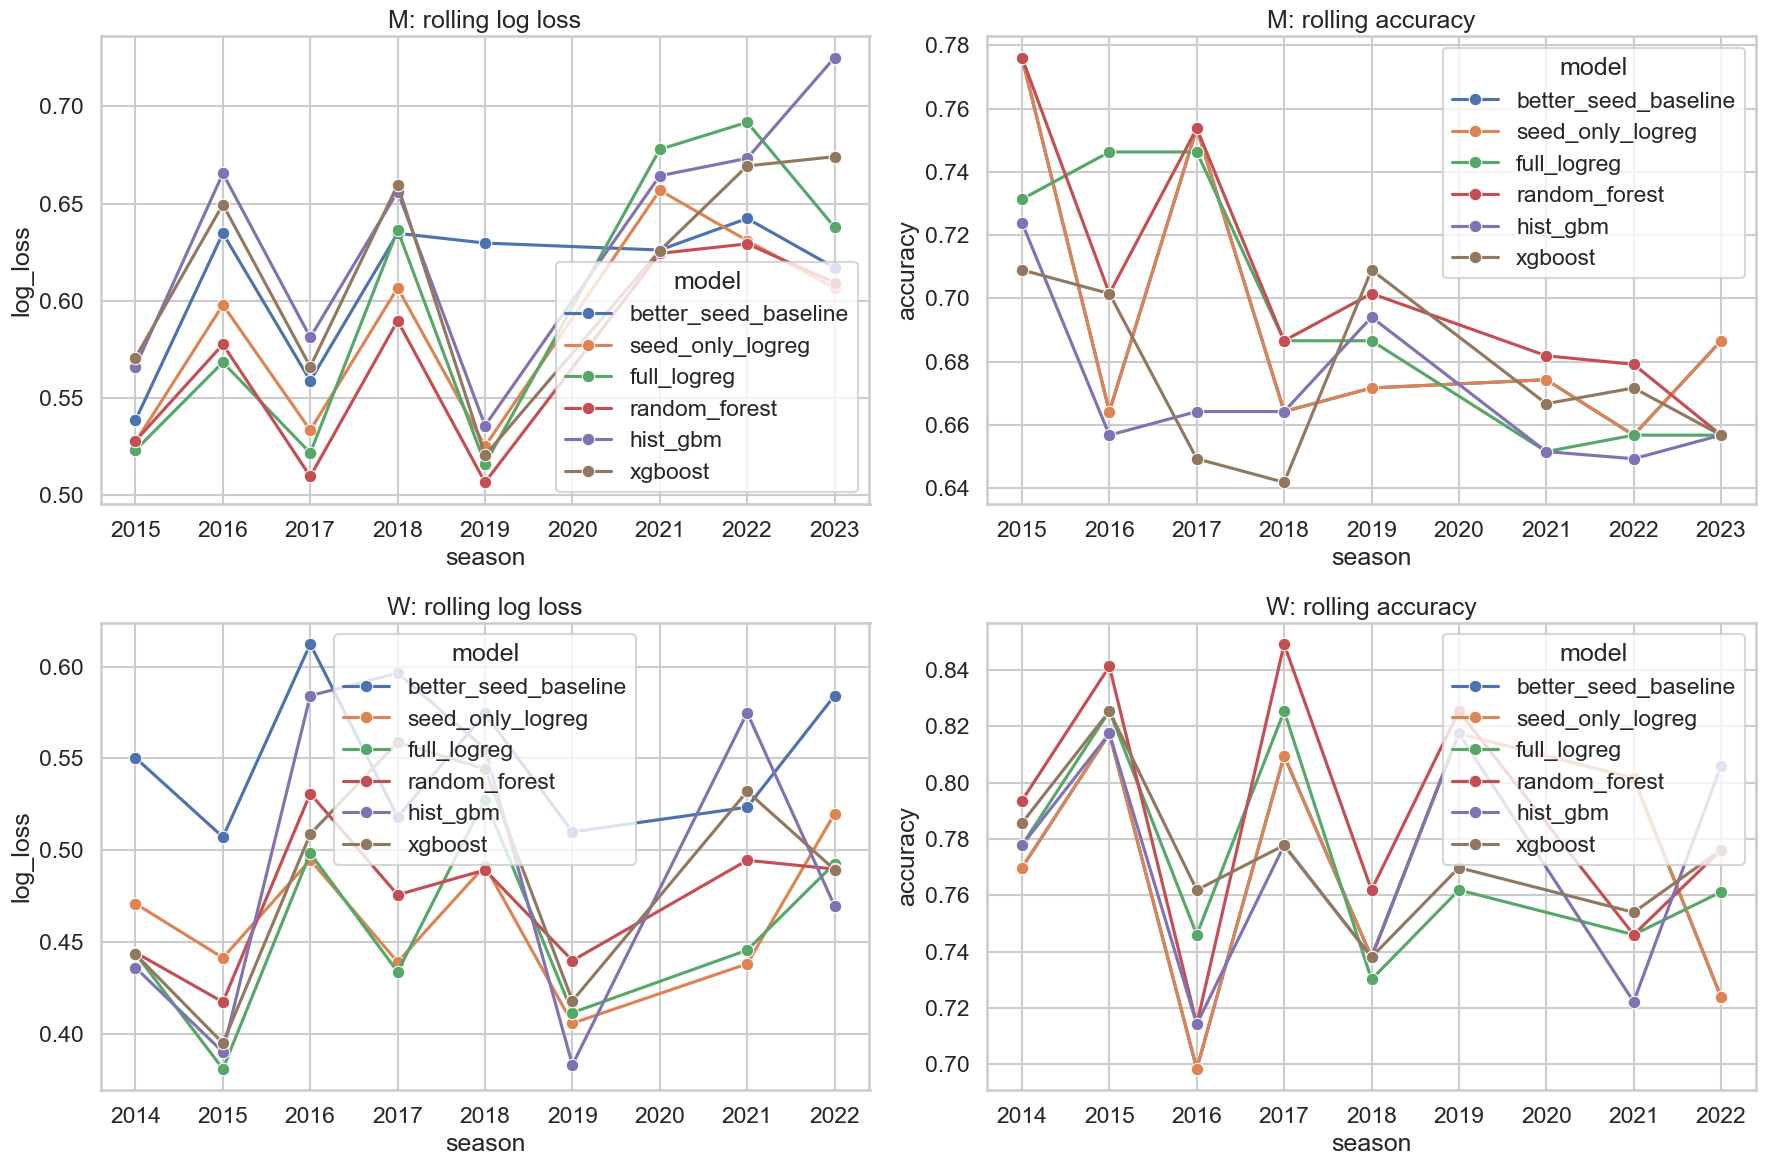

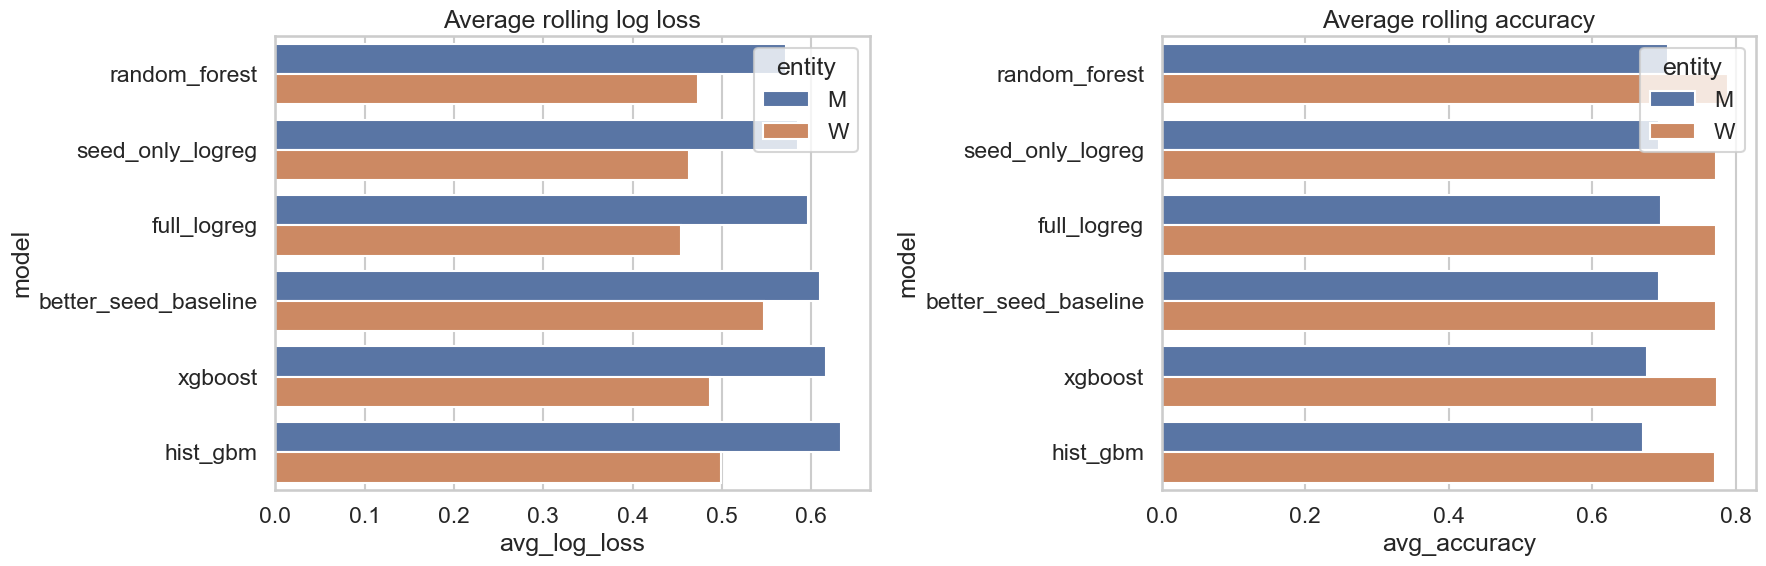

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for row_idx, entity in enumerate(sorted(backtest_metrics["entity"].unique())):
    subset = backtest_metrics[backtest_metrics["entity"] == entity]
    sns.lineplot(data=subset, x="season", y="log_loss", hue="model", marker="o", ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"{entity}: rolling log loss")
    sns.lineplot(data=subset, x="season", y="accuracy", hue="model", marker="o", ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"{entity}: rolling accuracy")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=leaderboard, x="avg_log_loss", y="model", hue="entity", ax=axes[0])
axes[0].set_title("Average rolling log loss")
sns.barplot(data=leaderboard, x="avg_accuracy", y="model", hue="entity", ax=axes[1])
axes[1].set_title("Average rolling accuracy")
plt.tight_layout()
plt.show()


,entity,model
0,M,random_forest
1,W,full_logreg


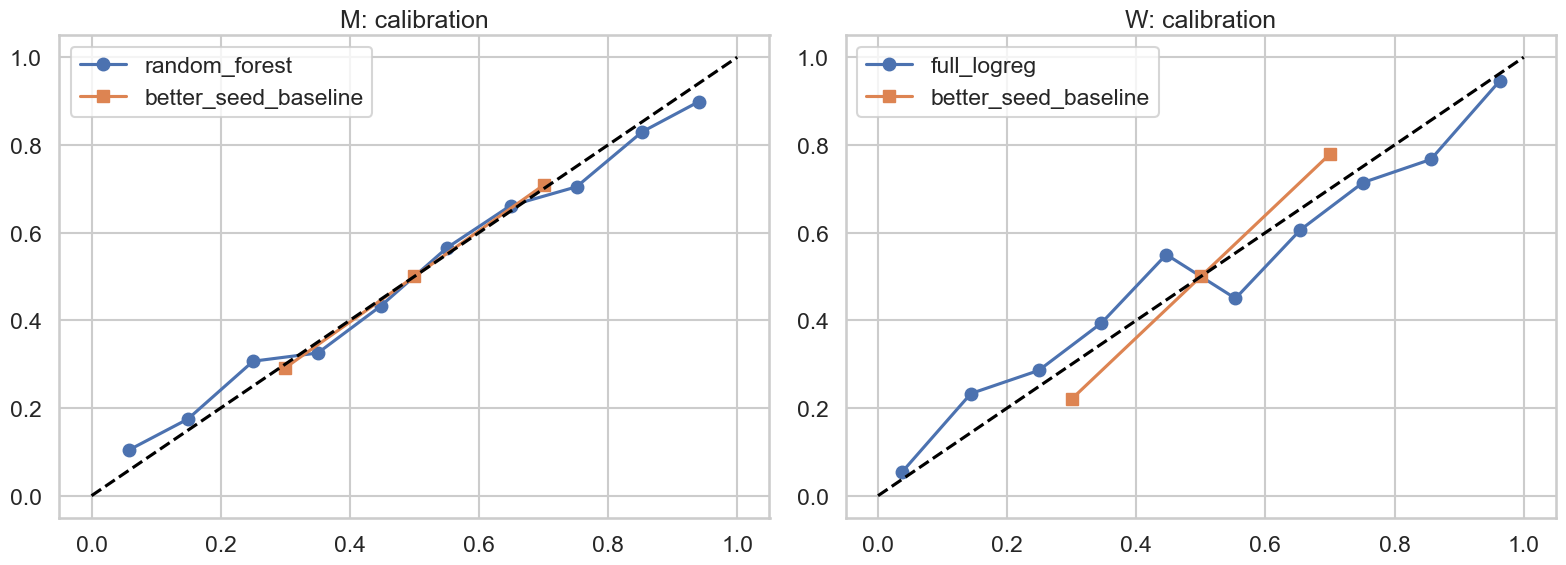

,entity,model,feature,importance
0,M,random_forest,seed_num_diff,0.245336
1,M,random_forest,avg_margin_diff,0.132270
2,M,random_forest,massey_std_diff,0.081775
3,M,random_forest,wins_diff,0.076412
4,M,random_forest,massey_mean_diff,0.062266
5,M,random_forest,massey_worst_diff,0.056493
6,M,random_forest,massey_median_diff,0.052865
7,M,random_forest,win_pct_diff,0.042344
8,M,random_forest,massey_best_diff,0.031558
9,M,random_forest,avg_points_for_diff,0.029973


In [9]:
best_models = leaderboard.sort_values(["entity", "avg_log_loss", "avg_brier"]).groupby("entity").head(1)[["entity", "model"]].reset_index(drop=True)
display(best_models)

fig, axes = plt.subplots(1, len(best_models), figsize=(8 * len(best_models), 6))
if len(best_models) == 1:
    axes = [axes]
for ax, row in zip(axes, best_models.to_dict("records")):
    entity, model_name = row["entity"], row["model"]
    subset = backtest_predictions[(backtest_predictions["entity"] == entity) & (backtest_predictions["model"] == model_name)]
    frac_pos, mean_pred = calibration_curve(subset["Target"], subset["pred_prob"], n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)
    base = backtest_predictions[(backtest_predictions["entity"] == entity) & (backtest_predictions["model"] == "better_seed_baseline")]
    frac_base, mean_base = calibration_curve(base["Target"], base["pred_prob"], n_bins=10)
    ax.plot(mean_base, frac_base, marker="s", label="better_seed_baseline")
    ax.plot([0, 1], [0, 1], "--", color="black")
    ax.set_title(f"{entity}: calibration")
    ax.legend()
plt.tight_layout()
plt.show()


importance_rows = []
for row in best_models.to_dict("records"):
    entity, model_name = row["entity"], row["model"]
    if model_name == "better_seed_baseline":
        continue
    frame, cols = matchup_frames[entity], feature_columns[entity]
    fitted = clone(make_model_specs(cols)[model_name]).fit(frame[cols], frame["Target"])
    estimator = fitted.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_[0])
    else:
        continue
    imp = pd.DataFrame({"entity": entity, "model": model_name, "feature": cols, "importance": importance}).sort_values("importance", ascending=False).head(15)
    importance_rows.append(imp)
importance_df = pd.concat(importance_rows, ignore_index=True)
display(importance_df)


## 4. Historical bracket simulation

The last step is to see how the best model behaves as an actual bracket engine, not just as a game-level classifier.


In [10]:
def season_slots(entity, season):
    slots = data[entity]["slots"]
    if slots is None:
        return None
    return slots[slots["Season"] == season].copy() if "Season" in slots.columns else slots.copy()


def build_seed_map(entity, season):
    seeds = data[entity]["seeds"]
    teams = data[entity]["teams"]
    work = seeds[seeds["Season"] == season].copy()
    work["seed_num"] = work["Seed"].map(parse_seed)
    if teams is not None:
        work = work.merge(teams[["TeamID", "TeamName"]], on="TeamID", how="left")
    return work


def actual_lookup(entity, season):
    tourney = data[entity]["tourney_compact"]
    season_games = tourney[tourney["Season"] == season].copy()
    return {tuple(sorted([int(r.WTeamID), int(r.LTeamID)])): int(r.WTeamID) for _, r in season_games.iterrows()}


def matchup_row(entity, season, team1, team2):
    feats = team_features[entity]
    left = feats[(feats["Season"] == season) & (feats["TeamID"] == team1)].add_suffix("_1")
    right = feats[(feats["Season"] == season) & (feats["TeamID"] == team2)].add_suffix("_2")
    row = pd.concat([left.reset_index(drop=True), right.reset_index(drop=True)], axis=1)
    for col in feature_columns[entity]:
        root = col[:-5]
        row[col] = row[root + "_1"] - row[root + "_2"]
    return row.iloc[0].to_dict()


def simulate_bracket(entity, season, model_name):
    model = None
    if model_name != "better_seed_baseline":
        cols = feature_columns[entity]
        fitted = clone(make_model_specs(cols)[model_name])
        train = matchup_frames[entity][matchup_frames[entity]["Season"] < season].copy()
        fitted.fit(train[cols], train["Target"])
        model = fitted

    slots = season_slots(entity, season)
    seed_df = build_seed_map(entity, season)
    seed_lookup = seed_df.set_index("Seed").to_dict("index")
    winners, rows = {}, []

    unresolved = slots.copy()
    while not unresolved.empty:
        progressed = False
        remaining = []
        for _, row in unresolved.iterrows():
            strong_ref, weak_ref = row["StrongSeed"], row["WeakSeed"]
            t1 = seed_lookup.get(strong_ref, {}).get("TeamID") if strong_ref in seed_lookup else winners.get(strong_ref)
            t2 = seed_lookup.get(weak_ref, {}).get("TeamID") if weak_ref in seed_lookup else winners.get(weak_ref)
            if t1 is None or t2 is None:
                remaining.append(row)
                continue
            if model_name == "better_seed_baseline":
                s1 = seed_lookup.get(strong_ref, {}).get("seed_num", np.nan) if strong_ref in seed_lookup else np.nan
                s2 = seed_lookup.get(weak_ref, {}).get("seed_num", np.nan) if weak_ref in seed_lookup else np.nan
                prob = better_seed_prob(s1, s2)
            else:
                prob = float(model.predict_proba(pd.DataFrame([matchup_row(entity, season, t1, t2)])[feature_columns[entity]])[:, 1][0])
            winner = t1 if prob >= 0.5 else t2
            winners[row["Slot"]] = winner
            rows.append({"Slot": row["Slot"], "StrongRef": strong_ref, "WeakRef": weak_ref, "Team1": t1, "Team2": t2, "PredWinner": winner, "PredProbTeam1": prob})
            progressed = True
        unresolved = pd.DataFrame(remaining)
        if not progressed:
            break

    out = pd.DataFrame(rows)
    name_map = data[entity]["teams"].set_index("TeamID")["TeamName"]
    out["Team1Name"] = out["Team1"].map(name_map)
    out["Team2Name"] = out["Team2"].map(name_map)
    out["PredWinnerName"] = out["PredWinner"].map(name_map)
    return out


def actual_slots(entity, season):
    slots = season_slots(entity, season)
    seed_df = build_seed_map(entity, season)
    seed_lookup = seed_df.set_index("Seed").to_dict("index")
    winners, rows = {}, []
    lookup = actual_lookup(entity, season)
    unresolved = slots.copy()
    while not unresolved.empty:
        progressed = False
        remaining = []
        for _, row in unresolved.iterrows():
            strong_ref, weak_ref = row["StrongSeed"], row["WeakSeed"]
            t1 = seed_lookup.get(strong_ref, {}).get("TeamID") if strong_ref in seed_lookup else winners.get(strong_ref)
            t2 = seed_lookup.get(weak_ref, {}).get("TeamID") if weak_ref in seed_lookup else winners.get(weak_ref)
            if t1 is None or t2 is None:
                remaining.append(row)
                continue
            winner = lookup.get(tuple(sorted([int(t1), int(t2)])))
            if winner is None:
                remaining.append(row)
                continue
            winners[row["Slot"]] = winner
            rows.append({"Slot": row["Slot"], "ActualWinner": winner})
            progressed = True
        unresolved = pd.DataFrame(remaining)
        if not progressed:
            break
    return pd.DataFrame(rows)


bracket_rows = []
bracket_predictions = {}
for row in best_models.to_dict("records"):
    entity, model_name = row["entity"], row["model"]
    season = int(matchup_frames[entity]["Season"].max())
    pred_best = simulate_bracket(entity, season, model_name)
    pred_base = simulate_bracket(entity, season, "better_seed_baseline")
    actual = actual_slots(entity, season)
    bracket_predictions[(entity, model_name)] = pred_best
    bracket_predictions[(entity, "better_seed_baseline")] = pred_base
    for name, pred in [(model_name, pred_best), ("better_seed_baseline", pred_base)]:
        merged = pred.merge(actual, on="Slot", how="left")
        bracket_rows.append({"entity": entity, "season": season, "model": name, "slot_accuracy": (merged["PredWinner"] == merged["ActualWinner"]).mean()})
bracket_summary_df = pd.DataFrame(bracket_rows)
display(bracket_summary_df)


,entity,season,model,slot_accuracy
0,M,2023,random_forest,0.537313
1,M,2023,better_seed_baseline,0.552239
2,W,2022,full_logreg,0.711111
3,W,2022,better_seed_baseline,0.711111


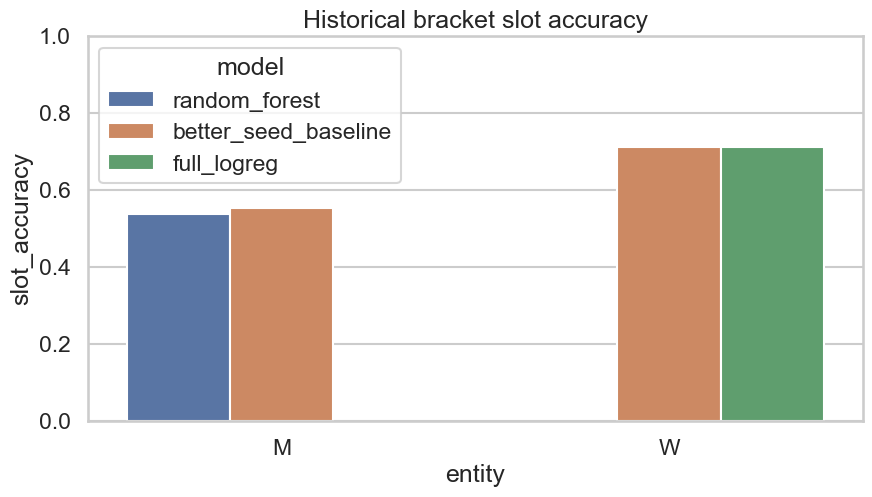

### M: historical bracket board using `random_forest`

,Slot,StrongRef,WeakRef,Team1,Team2,PredWinner,PredProbTeam1,Team1Name,Team2Name,PredWinnerName
48,R1W1,W01,W16,1345,1411,1345,0.935252,Purdue,TX Southern,Purdue
0,R1W2,W02,W15,1266,1436,1266,0.905390,Marquette,Vermont,Marquette
1,R1W3,W03,W14,1243,1286,1243,0.853120,Kansas St,Montana St,Kansas St
2,R1W4,W04,W13,1397,1418,1397,0.882489,Tennessee,Louisiana,Tennessee
3,R1W5,W05,W12,1181,1331,1181,0.717049,Duke,Oral Roberts,Duke
4,R1W6,W06,W11,1246,1344,1246,0.683612,Kentucky,Providence,Kentucky
5,R1W7,W07,W10,1277,1425,1277,0.508595,Michigan St,USC,Michigan St
6,R1W8,W08,W09,1272,1194,1272,0.525994,Memphis,FL Atlantic,Memphis
49,R1X1,X01,X16,1104,1394,1104,0.873749,Alabama,TAM C. Christi,Alabama
7,R1X2,X02,X15,1112,1343,1112,0.906516,Arizona,Princeton,Arizona


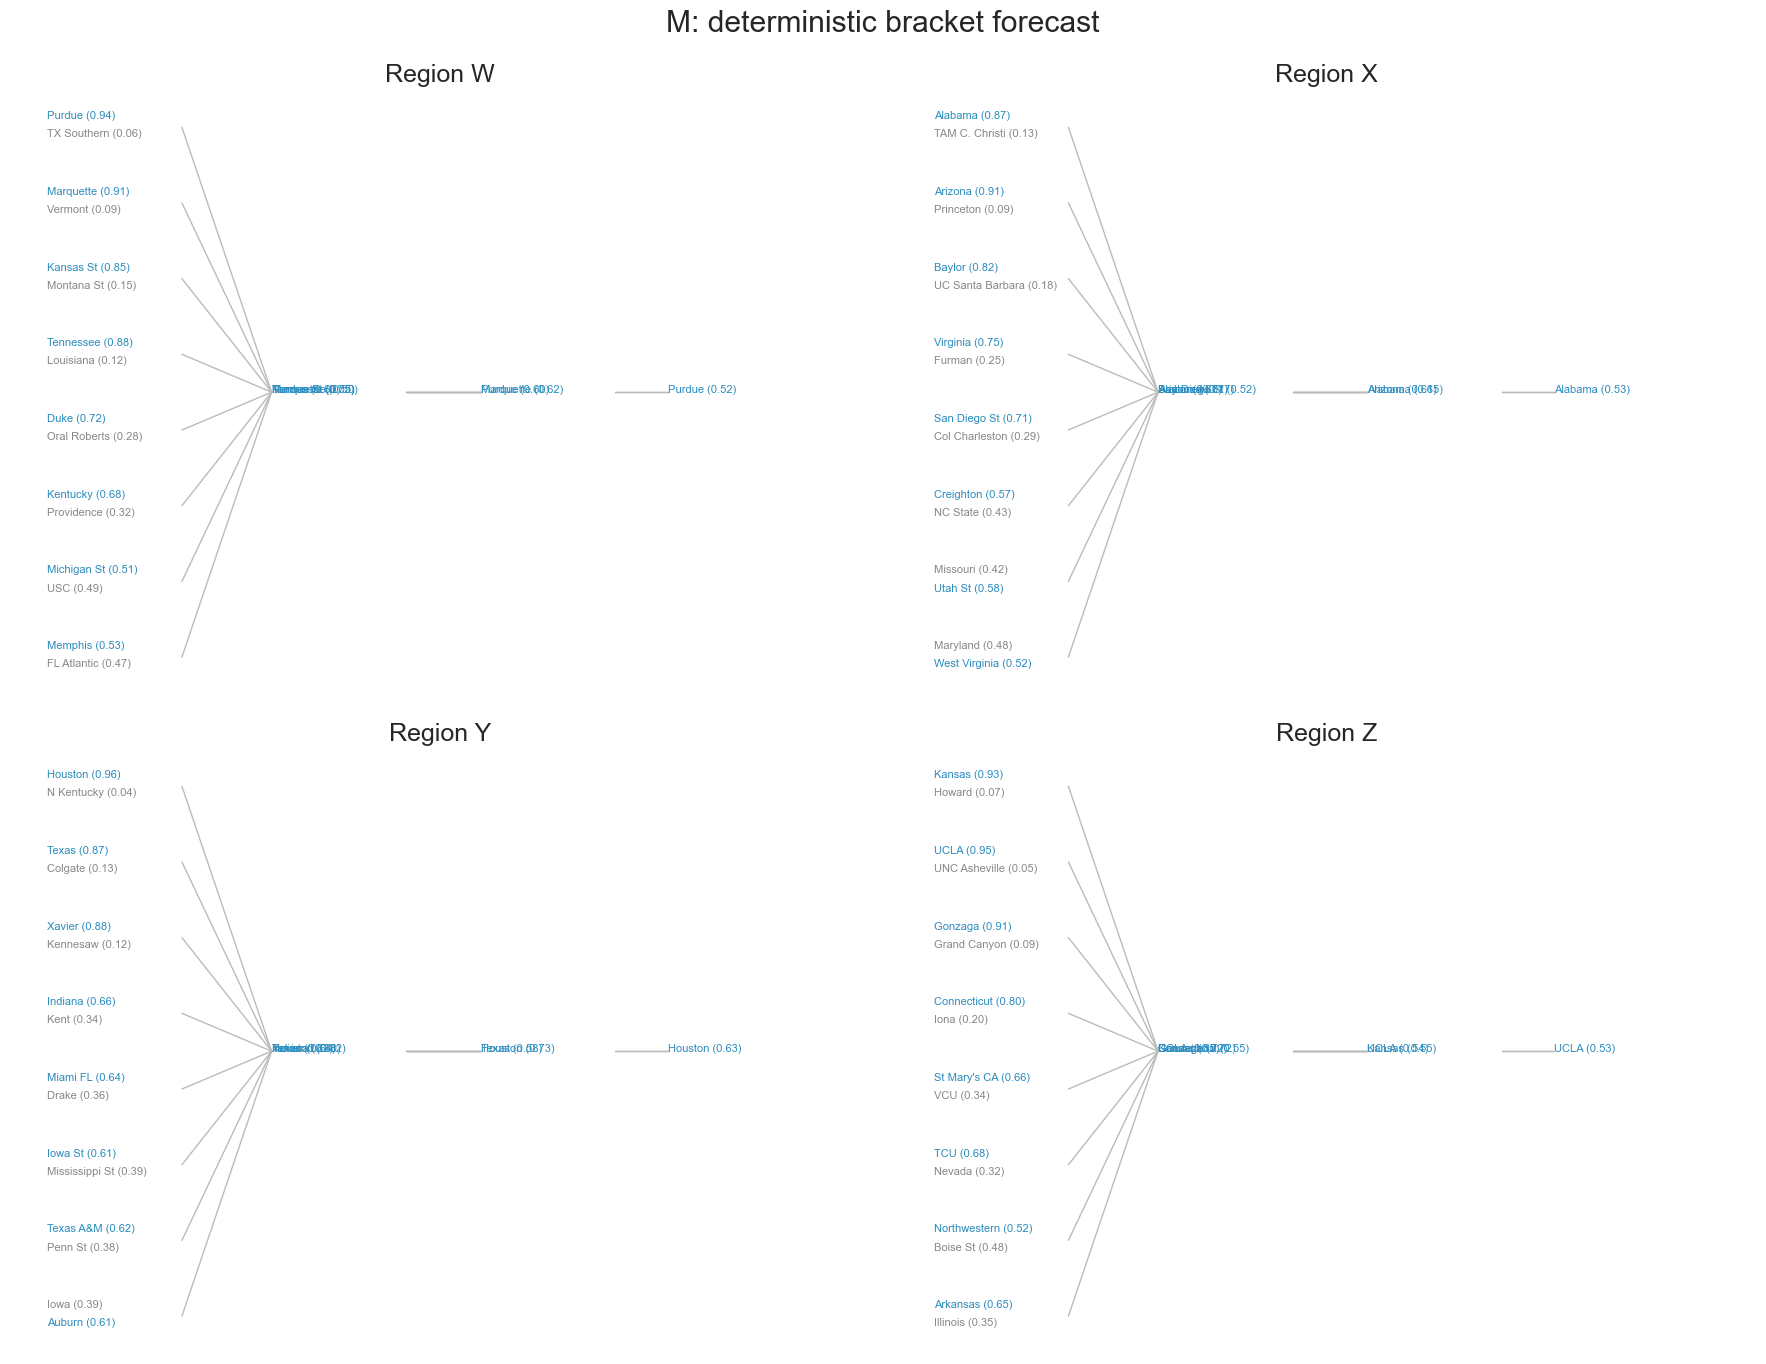

### W: historical bracket board using `full_logreg`

,Slot,StrongRef,WeakRef,Team1,Team2,PredWinner,PredProbTeam1,Team1Name,Team2Name,PredWinnerName
0,R1W2,W02,W15,3163,3273,3163,0.983640,Connecticut,Mercer,Connecticut
1,R1W3,W03,W14,3231,3150,3231,0.929781,Indiana,Charlotte,Indiana
2,R1W4,W04,W13,3328,3237,3328,0.850904,Oklahoma,IUPUI,Oklahoma
3,R1W5,W05,W12,3323,3269,3323,0.850358,Notre Dame,Massachusetts,Notre Dame
4,R1W6,W06,W11,3246,3343,3246,0.625189,Kentucky,Princeton,Kentucky
5,R1W7,W07,W10,3416,3196,3416,0.668451,UCF,Florida,UCF
6,R1W8,W08,W09,3450,3243,3243,0.291411,Washington St,Kansas St,Kansas St
7,R1X1,X01,X16,3390,3286,3390,0.977482,Stanford,Montana St,Stanford
8,R1X2,X02,X15,3400,3193,3400,0.971724,Texas,Fairfield,Texas
9,R1X3,X03,X14,3261,3238,3261,0.902674,LSU,Jackson St,LSU


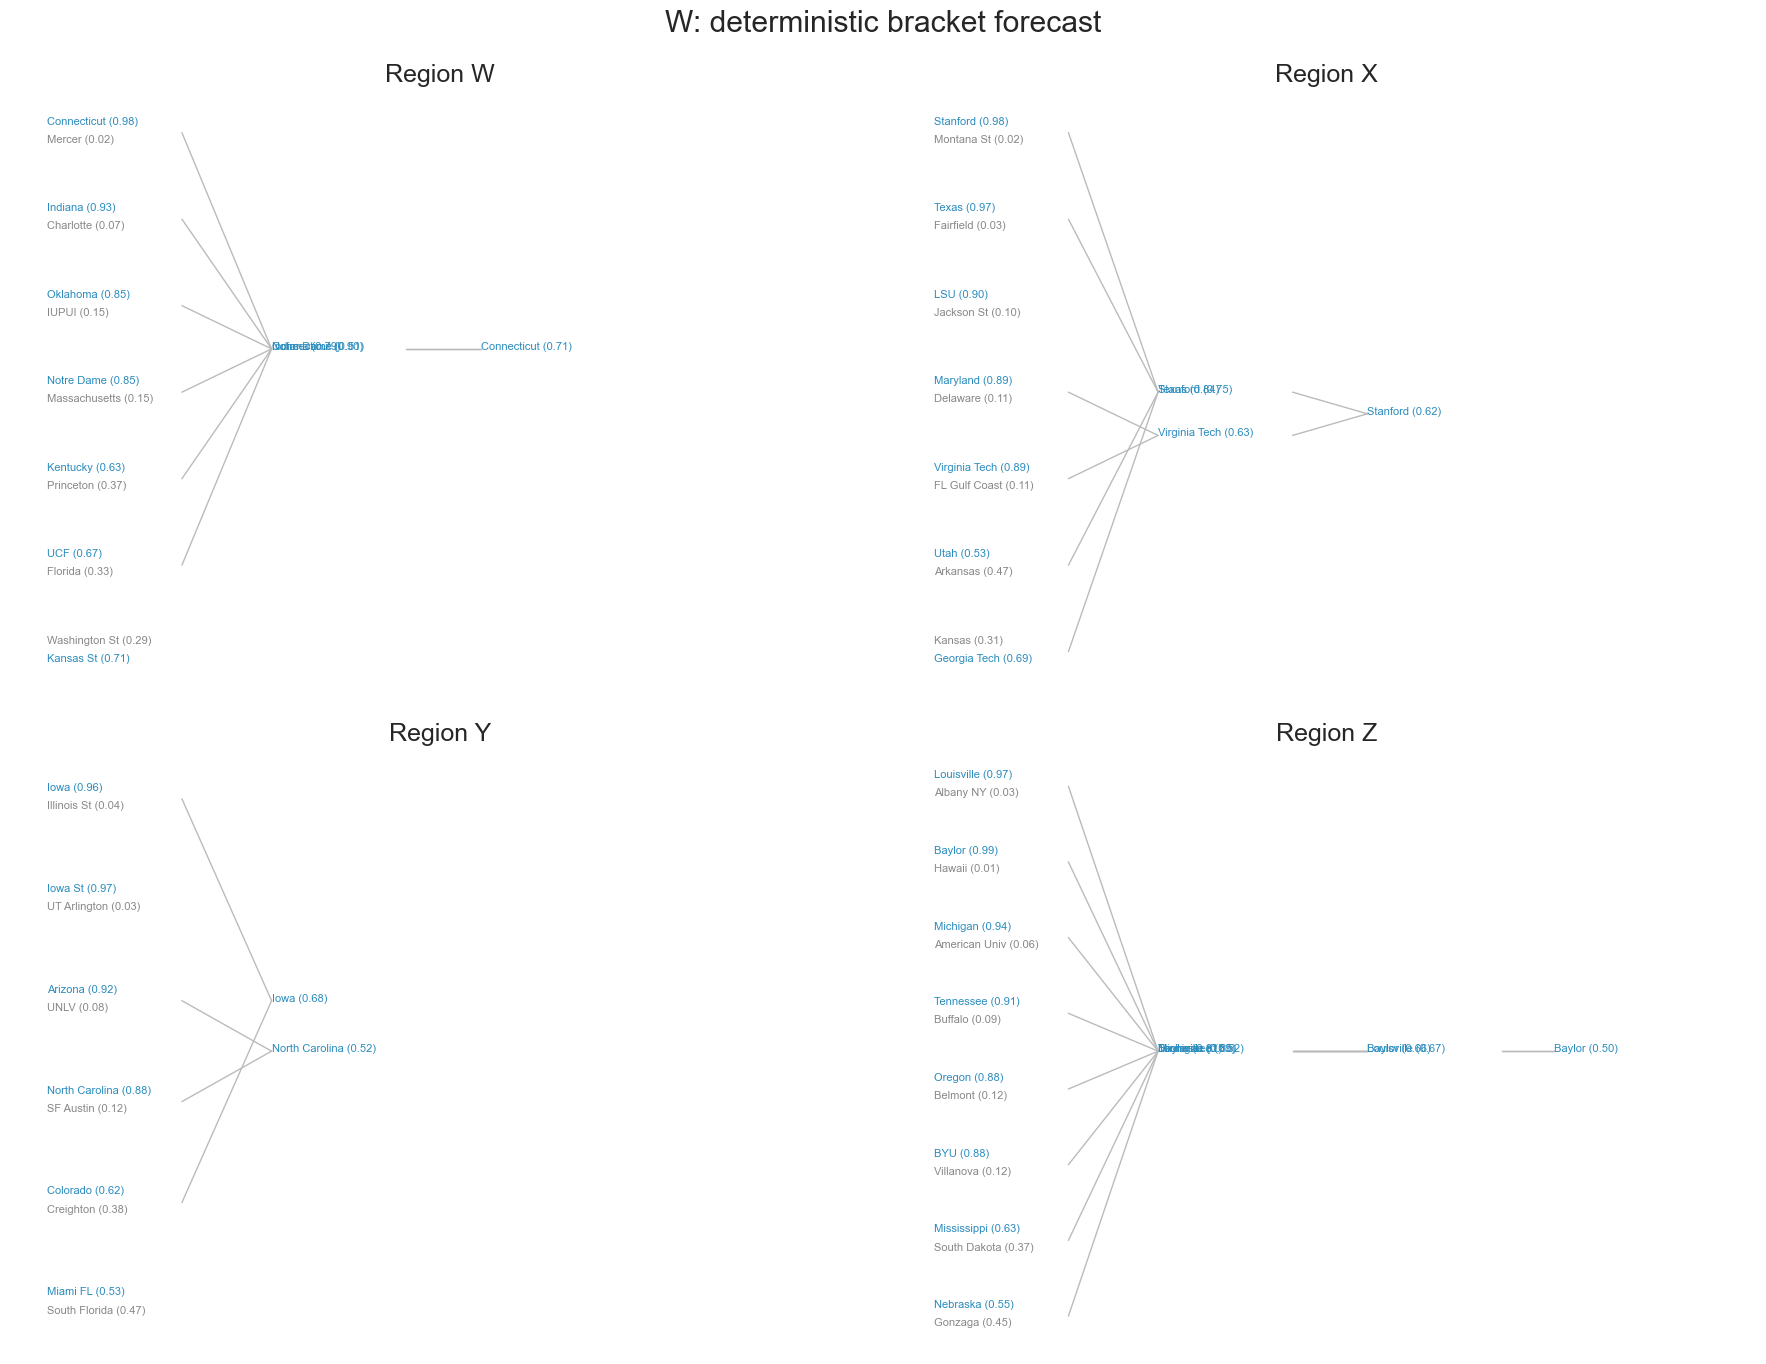

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=bracket_summary_df, x="entity", y="slot_accuracy", hue="model")
plt.ylim(0, 1)
plt.title("Historical bracket slot accuracy")
plt.show()


def slot_region(slot):
    m = re.search(r"([WXYZ])", str(slot))
    return m.group(1) if m else "F"


def slot_round(slot):
    m = re.match(r"R(\d+)", str(slot))
    return int(m.group(1)) if m else 5


def draw_region(ax, region_name, pred_df):
    df = pred_df[pred_df["Slot"].map(slot_region) == region_name].copy()
    if df.empty:
        ax.axis("off")
        return
    df["round_num"] = df["Slot"].map(slot_round)
    df = df.sort_values(["round_num", "Slot"]).reset_index(drop=True)
    x_map = {1: 0.05, 2: 0.35, 3: 0.63, 4: 0.88}
    y_slots = {}
    r1 = df[df["round_num"] == 1].sort_values("Slot")
    for idx, (_, row) in enumerate(r1.iterrows()):
        y = 1 - (idx + 0.5) / len(r1)
        y_slots[row["Slot"]] = y
        ax.text(x_map[1], y + 0.015, f"{row['Team1Name']} ({row['PredProbTeam1']:.2f})", fontsize=8, color="#2b8cbe" if row["PredWinner"] == row["Team1"] else "#888888")
        ax.text(x_map[1], y - 0.015, f"{row['Team2Name']} ({1-row['PredProbTeam1']:.2f})", fontsize=8, color="#2b8cbe" if row["PredWinner"] == row["Team2"] else "#888888")
    for round_num in sorted(df["round_num"].unique()):
        if round_num == 1:
            continue
        sub = df[df["round_num"] == round_num].sort_values("Slot")
        for _, row in sub.iterrows():
            y1 = y_slots.get(row["StrongRef"])
            y2 = y_slots.get(row["WeakRef"])
            if y1 is None or y2 is None:
                continue
            y = (y1 + y2) / 2
            y_slots[row["Slot"]] = y
            ax.plot([x_map[round_num - 1] + 0.18, x_map[round_num]], [y1, y], color="#bbbbbb", lw=1)
            ax.plot([x_map[round_num - 1] + 0.18, x_map[round_num]], [y2, y], color="#bbbbbb", lw=1)
            win_prob = row["PredProbTeam1"] if row["PredWinner"] == row["Team1"] else 1 - row["PredProbTeam1"]
            ax.text(x_map[round_num], y, f"{row['PredWinnerName']} ({win_prob:.2f})", fontsize=8, color="#2b8cbe")
    ax.set_title(f"Region {region_name}")
    ax.set_xlim(0, 1.15)
    ax.set_ylim(0, 1)
    ax.axis("off")


for row in best_models.to_dict("records"):
    entity, model_name = row["entity"], row["model"]
    pred = bracket_predictions[(entity, model_name)]
    display(Markdown(f"### {entity}: historical bracket board using `{model_name}`"))
    display(pred.sort_values('Slot').head(20))
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    for ax, region in zip(axes.flatten(), ["W", "X", "Y", "Z"]):
        draw_region(ax, region, pred)
    plt.suptitle(f"{entity}: deterministic bracket forecast")
    plt.tight_layout()
    plt.show()


## 5. Decision summary and optional latent model

The summary table below is the practical answer sheet.


In [12]:
decision_rows = []
for entity in sorted(leaderboard["entity"].unique()):
    prob_best = leaderboard[leaderboard["entity"] == entity].sort_values("avg_log_loss").iloc[0]
    bracket_best = bracket_summary_df[bracket_summary_df["entity"] == entity].sort_values("slot_accuracy", ascending=False).iloc[0]
    decision_rows.append({
        "entity": entity,
        "best_probability_model": prob_best["model"],
        "avg_log_loss": prob_best["avg_log_loss"],
        "best_bracket_model": bracket_best["model"],
        "bracket_slot_accuracy": bracket_best["slot_accuracy"],
    })
decision_df = pd.DataFrame(decision_rows)
display(decision_df)

RUN_LATENT_SECTION = False
if RUN_LATENT_SECTION and HAS_PYMC:
    entity = "M"
    latest = data[entity]["regular_detailed"]
    season = int(latest["Season"].max())
    sample = latest[latest["Season"] == season].sample(n=min(1500, len(latest[latest["Season"] == season])), random_state=RANDOM_STATE).copy()
    teams = pd.Index(sorted(set(sample["WTeamID"]).union(set(sample["LTeamID"]))))
    team_to_idx = {team: i for i, team in enumerate(teams)}
    i = sample["WTeamID"].map(team_to_idx).to_numpy()
    j = sample["LTeamID"].map(team_to_idx).to_numpy()
    wi = sample["WScore"].to_numpy()
    wj = sample["LScore"].to_numpy()
    home = (sample["WLoc"] == "H").astype(int) - (sample["WLoc"] == "A").astype(int)

    with pm.Model(coords={"team": teams.values, "game": np.arange(len(sample))}) as latent_model:
        mu_intercept = pm.Normal("mu_intercept", mu=70, sigma=10)
        off = pm.Normal("off", mu=0, sigma=10, dims="team")
        deff = pm.Normal("deff", mu=0, sigma=10, dims="team")
        alpha = pm.Normal("alpha", mu=1.5, sigma=2.0)
        sigma = pm.HalfNormal("sigma", sigma=15)
        pm.Normal("score_i", mu=mu_intercept + off[i] - deff[j] + alpha * home, sigma=sigma, observed=wi, dims="game")
        pm.Normal("score_j", mu=mu_intercept + off[j] - deff[i] - alpha * home, sigma=sigma, observed=wj, dims="game")
        idata = pm.sample(draws=750, tune=750, chains=2, target_accept=0.9, random_seed=RANDOM_STATE, progressbar=True)
    az.summary(idata, var_names=["mu_intercept", "alpha", "sigma"])
else:
    print("Latent section skipped. Set RUN_LATENT_SECTION = True to sample the optional offense-defense model.")


,entity,best_probability_model,avg_log_loss,best_bracket_model,bracket_slot_accuracy
0,M,random_forest,0.571772,better_seed_baseline,0.552239
1,W,full_logreg,0.454285,full_logreg,0.711111


Latent section skipped. Set RUN_LATENT_SECTION = True to sample the optional offense-defense model.
